In [8]:
# from euclid_generator import EuclidGenerator
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp

In [ ]:
gen = EuclidGenerator("images/", 15)

In [10]:

lens_EPL_kwargs = {
    'theta_E' : 2.0, 
    'gamma': np.random.uniform(1.7, 2.3),
    'e1': 0.1,
    'e2': 0.1,
    'center_x': 0.0,
    'center_y': 0.0
}
lens_shear_kwargs = {
    'gamma1': np.random.uniform(0.0, 0.3),     
    'gamma2':np.random.uniform(0.0, 0.3),      
    'ra_0': lens_EPL_kwargs['center_x'],
    'dec_0': lens_EPL_kwargs['center_y'],
}
lens_mass_kwargs = [lens_EPL_kwargs, lens_shear_kwargs]

# --- dumy source 1 kwargs --- #
source1_SIS_kwargs = {
    'theta_E' : 0.0, 
    'center_x': 0.0,    
    'center_y': 0.0    
}
source1_shear_kwargs = {
    'gamma1': 0.0,     
    'gamma2': 0.0,      
    'ra_0': 0.0,
    'dec_0': 0.0,
}
source1_mass_kwargs = [source1_SIS_kwargs, source1_shear_kwargs]

mp_mass_kwargs = [lens_mass_kwargs, source1_mass_kwargs]
eta = 2

In [25]:
def get_inverse_magnification(self, x, y, mass_kwargs, eta, plane):
    A = self.mass_model.A( x=x, y=y, kwargs=mass_kwargs, eta_flat=eta )
    Ap = A[plane, :, :]
    return Ap[..., 0, 0] * Ap[..., 1, 1] - Ap[..., 0, 1] * Ap[..., 1, 0]

In [26]:
x_vec = jnp.linspace(-20.0, 20.0, 100)
y_vec = jnp.linspace(-20.0, 20.0, 100)
X, Y = jnp.meshgrid(x_vec, y_vec)

mu_inv = get_inverse_magnification(gen, X, Y, mp_mass_kwargs, eta, 1)
print(mu_inv.shape)

(100, 100)


In [9]:
from astropy.io import fits
import matplotlib.pyplot as plt
import os

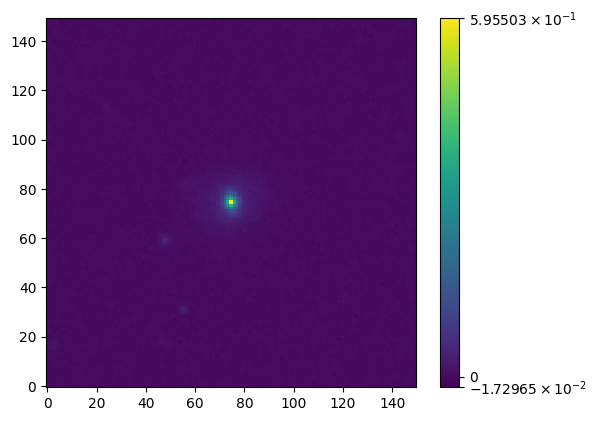

In [27]:
with os.scandir("lrg_used_for_karina_sim/") as entries:
    lens_files = np.array([item.name for item in entries])

with fits.open("lrg_used_for_karina_sim/" + lens_files[6]) as hdul:
    image_header = hdul[1].header
    image_data = hdul[1].data
    
    # print(image_hexader)
    plt.imshow(image_data, origin='lower', norm="symlog")
    plt.colorbar()
    plt.show()


In [109]:
with fits.open("lrg_used_for_karina_sim/EUC_12538_DESI-sel.fits") as hdul:
    print(hdul.info())

Filename: lrg_used_for_karina_sim/EUC_12538_DESI-sel.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      16   ()      
  1  VIS_FLUX      1 ImageHDU        62   (150, 150)   float32   
  2  VIS_PSF       1 ImageHDU         9   (21, 21)   float32   
  3  VIS_RMS       1 ImageHDU         8   (150, 150)   float32   
  4  NIR_Y_FLUX    1 ImageHDU        62   (150, 150)   float32   
  5  NIR_Y_PSF     1 ImageHDU         9   (33, 33)   float32   
  6  NIR_Y_RMS     1 ImageHDU         8   (150, 150)   float32   
  7  NIR_J_FLUX    1 ImageHDU        62   (150, 150)   float32   
  8  NIR_J_PSF     1 ImageHDU         9   (33, 33)   float32   
  9  NIR_J_RMS     1 ImageHDU         8   (150, 150)   float32   
 10  NIR_H_FLUX    1 ImageHDU        62   (150, 150)   float32   
 11  NIR_H_PSF     1 ImageHDU         9   (33, 33)   float32   
 12  NIR_H_RMS     1 ImageHDU         8   (150, 150)   float32   
None


In [145]:
import numpy as np
import jax.numpy as jnp

from herculens.Util import param_util

import numpy as np

import jax
import jax.numpy as jnp
from jax_zero_contour import ZeroSolver
from jax import random

from functools import partial

import matplotlib.pyplot as plt

from skimage import measure
from scipy.ndimage import map_coordinates
from scipy.interpolate import splprep, splev

import numpyro
import numpyro.distributions as dist

from herculens.Coordinates.pixel_grid import PixelGrid
from herculens.Instrument.noise import Noise
from herculens.Instrument.psf import PSF

from herculens.MassModel.mass_model import MassModel
from herculens.LightModel.light_model import LightModel
from herculens.LensImage.lens_image import LensImage

from herculens.MassModel.mass_model_multiplane import MPMassModel
from herculens.LightModel.light_model_multiplane import MPLightModel
from herculens.LensImage.lens_image_multiplane import MPLensImage

import os


In [111]:
def get_shape_of_source(source_img, threshold=0.1):
    """
    Calculates the axis ratio and position angle from the image of a source, returns as (e1, e2) ellipticity parameters.
    """

    mask = source_img > (threshold * source_img.max())

    y, x = np.indices(source_img.shape)
    # x, y = source_coords
    I = source_img * mask  # masked image

    # Compute centroid
    x_c = (I * x).sum() / I.sum()
    y_c = (I * y).sum() / I.sum()

    # Centered coordinates
    x_cen = x - x_c
    y_cen = y - y_c

    # Second moments
    Mxx = (I * x_cen**2).sum() / I.sum()
    Myy = (I * y_cen**2).sum() / I.sum()
    Mxy = (I * x_cen * y_cen).sum() / I.sum()

    # Inertia tensor
    M = jnp.array([[Mxx, Mxy],
                  [Mxy, Myy]])

    # Eigen decomposition
    evals, evecs = jnp.linalg.eigh(M)
    order = jnp.argsort(evals)[::-1]
    evals = evals[order]
    evecs = evecs[:, order]

    major, minor = jnp.sqrt(evals)
    axis_ratio = minor / major
    pos_angle = jnp.arctan2(evecs[1, 0], evecs[0, 0])  # radians
    
    e1_src, e2_src = param_util.phi_q2_ellipticity(pos_angle, axis_ratio)

    return e1_src, e2_src

In [133]:
e1, e2 = get_shape_of_source(source_img = image_data[40:100, 40:100])

In [134]:
print(e1, e2)

-0.03982008 0.0085230535


In [135]:
phi, q = param_util.ellipticity2phi_q(e1, e2)
phi = np.degrees(phi)

print(q, phi)

0.92174274 83.95937


In [136]:
lens_EPL_kwargs = {
    "theta_E" : 1.0,
    "gamma" : 2.0,
    "e1" : e1,
    "e2" : e2,
    "center_x" : 0.0,
    "center_y" : 0.0
}

lens_mass_kwargs = [lens_EPL_kwargs]

In [137]:
mm = MassModel(["EPL"])

In [138]:
x_vec = np.linspace(-17, 17, image_data.shape[0])
y_vec = np.linspace(-17, 17, image_data.shape[0])
X, Y = np.meshgrid(x_vec, y_vec)

kappa = mm.kappa(X, Y, lens_mass_kwargs)

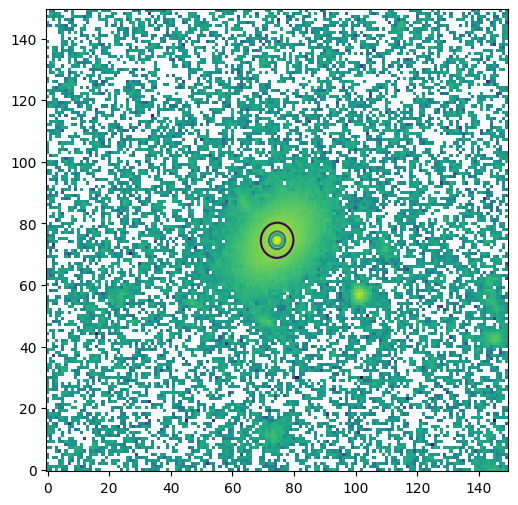

In [139]:
plt.figure(figsize=(6,6))

plt.imshow(image_data, norm="log")
plt.contour(kappa, norm="log")
plt.show()

In [149]:
lens_mass_model = MassModel(['EPL'])
lens_light_model = LightModel(['SERSIC_ELLIPSE'])
source_light_model = LightModel(['SERSIC_ELLIPSE', "MULTIPOLE", "MULTIPOLE"])

In [207]:
lens_mass_kwargs = [{
    'theta_E' : 1.0,
    'gamma' : 2.0,
    'e1' : 0.1,
    'e2' : 0.1,
    'center_x' : 0.0,
    'center_y' : 0.0
}]

lens_light_kwargs = [{
    'amp': 10.0,
    'R_sersic': 2.0,    # TODO
    'n_sersic': 4.0,    # TODO 
    'e1': lens_mass_kwargs[0]['e1'],          
    'e2': lens_mass_kwargs[0]['e1'],          
    'center_x': lens_mass_kwargs[0]['center_x'], 
    'center_y': lens_mass_kwargs[0]['center_y']
}]

source_light_kwargs = [{
    'amp': 5.0,
    'R_sersic': 1.0,    # TODO
    'n_sersic': 4.0,    # TODO 
    'e1': 0.2,          
    'e2': -0.1,          
    'center_x': 2.0, 
    'center_y': 3.0
},{
    'm' : 3,
    "amp_m" : 0.2,
    "phi_m" : np.pi/4,
    'center_x' : 2.0,
    'center_y' : 3.0
},{
    'm' : 4,
    "amp_m" : 0.1,
    "phi_m" : np.pi/18,
    'center_x' : 2.0,
    'center_y' : 3.0
}
]

In [208]:
pixel_grid = PixelGrid(51, 51)
psf = PSF('GAUSSIAN', pixel_size=0.1, fwhm=0.2)
lens_image = LensImage(pixel_grid, psf, lens_mass_model_class=lens_mass_model, lens_light_model_class=lens_light_model, source_model_class=source_light_model)

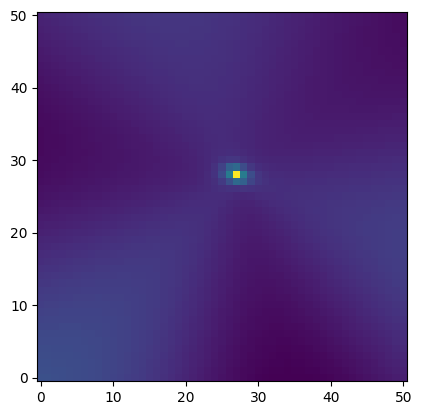

In [209]:
x_grid, y_grid = pixel_grid.pixel_coordinates
source_prof = source_light_model.surface_brightness(x=x_grid, y=y_grid, kwargs=source_light_kwargs) # bare in mind that this is computed from image plane coordinates

plt.imshow(source_prof, norm="symlog")
plt.show()

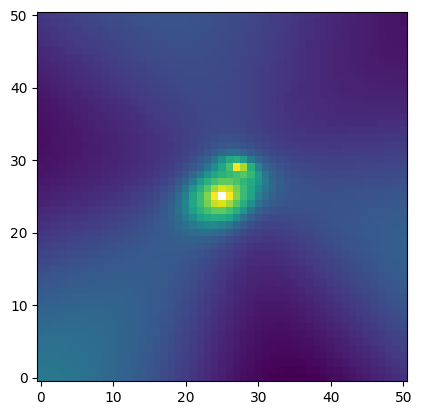

In [210]:
img = lens_image.model(
    kwargs_lens=lens_mass_kwargs,
    kwargs_source=source_light_kwargs,
    kwargs_lens_light=lens_light_kwargs
)

plt.imshow(img, norm="symlog")
plt.show()

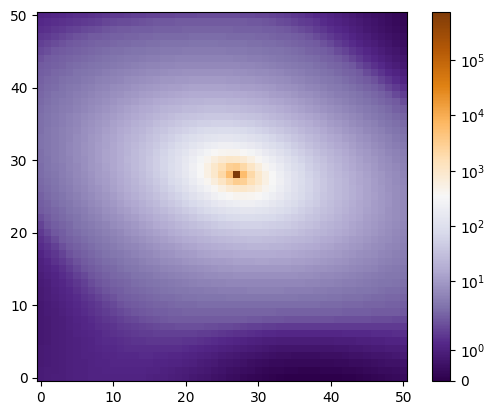

In [232]:
source_light_model = LightModel(['SERSIC_ELLIPSE', 'MULTIPOLE', 'MULTIPOLE'])

source_light_kwargs = [{
    'amp': 1_000,
    'R_sersic': 3.0,    # TODO
    'n_sersic': 4.0,    # TODO 
    'e1': 0.2,          
    'e2': -0.1,          
    'center_x': 2.0, 
    'center_y': 3.0
},{
    'm' : 3,
    "amp_m" : 0.1,
    "phi_m" : np.pi/4,
    'center_x' : 2.0,
    'center_y' : 3.0
},{
    'm' : 4,
    "amp_m" : 0.2,
    "phi_m" : np.pi/9,
    'center_x' : 2.0,
    'center_y' : 3.0
}
]

light_prof = source_light_model.surface_brightness(x=x_grid, y=y_grid, kwargs=source_light_kwargs)

plt.imshow(light_prof, origin='lower', cmap="PuOr_r", norm="symlog")
plt.colorbar()
plt.show()